 Capillary Bridge Force Analysis Notebook

# 1. Setup & Imports

In [2]:
import sys
from pathlib import Path
import json
from pprint import pprint

cfg = json.load(open(r"Analysis_Files\config.json"))
image_dir = Path(cfg["image_dir"])
mask_dir  = Path(cfg["mask_dir"])
output_dir = Path(cfg["output_dir"])
lines_file = Path(cfg["lines_file"])
label_clf = Path(cfg["label_clf_path"])
side_clf  = Path(cfg["side_clf_path"])
excel_out = Path(cfg["output_dir"]) / cfg["excel_output"]
debug_dir = Path(cfg["output_dir"]) / cfg["debug_image_dir"]
first_frame_spacing = cfg["first_frame_spacing"]
sigma_surface_tension = cfg["sigma_surface_tension"]
pprint(cfg)

{'debug_image_dir': 'D:\\Capillary_bridging_data_alannah\\Silane Capillary '
                    'Action\\3aminopropyl_07.22_Trial1_VidImages\\output\\debug_images',
 'excel_output': 'Alannah_S1_training.xlsx',
 'first_frame_spacing': 5e-05,
 'image_dir': 'D:\\Capillary_bridging_data_alannah\\Silane Capillary '
              'Action\\3aminopropyl_07.22_Trial1_VidImages',
 'label_clf_path': 'Analysis_Files\\Classifier_files\\trained_classifiers\\mask_edge_classifier3.pkl',
 'lines_file': 'D:\\Capillary_bridging_data_alannah\\Silane Capillary '
               'Action\\3aminopropyl_07.22_Trial1_VidImages\\output\\Alannah_S1_substrates.npz',
 'mask_dir': 'D:\\Capillary_bridging_data_alannah\\Silane Capillary '
             'Action\\3aminopropyl_07.22_Trial1_VidImages\\masks_json',
 'output_dir': 'D:\\Capillary_bridging_data_alannah\\Silane Capillary '
               'Action\\3aminopropyl_07.22_Trial1_VidImages\\output',
 'side_clf_path': 'Analysis_Files\\Classifier_files\\trained_classifie

In [3]:
#select new image folder path,and mask folder path, and output folder path
import tkinter as tk
from tkinter import filedialog
root = tk.Tk()
root.withdraw()  # Hide the root window
#keep the dialong on top
root.attributes('-topmost', True)

image_dir = Path(filedialog.askdirectory(title="Select Image Folder", initialdir=image_dir))
mask_dir = Path(filedialog.askdirectory(title="Select Mask Folder", initialdir=image_dir))
output_dir = Path(filedialog.askdirectory(title="Select Output Folder", initialdir=image_dir))
lines_file = output_dir / "Alannah_S1_substrates.npz"
debug_dir = output_dir / "debug_images"
#rewrite the config file with the new paths
cfg["image_dir"] = str(image_dir)
cfg["mask_dir"] = str(mask_dir)
cfg["output_dir"] = str(output_dir)
cfg["lines_file"] = str(lines_file)
cfg["debug_image_dir"] = str(debug_dir)
with open("Analysis_Files/config.json", "w") as f:
    json.dump(cfg, f, indent=4)
print(f"Image directory set to: {image_dir}")
print(f"Mask directory set to: {mask_dir}")
print(f"Output directory set to: {output_dir}")

Image directory set to: D:\Capillary_bridging_data_alannah\Silane Capillary Action\3aminopropyl_07.22_Trial3_VidImages
Mask directory set to: D:\Capillary_bridging_data_alannah\Silane Capillary Action\3aminopropyl_07.22_Trial3_VidImages\masks_json
Output directory set to: D:\Capillary_bridging_data_alannah\Silane Capillary Action\3aminopropyl_07.22_Trial3_VidImages\Output_Trial3


# 2. Define Substrate Lines

In [4]:
%matplotlib qt
%run Analysis_Files\Substrate_tests\define_substrate_lines.py


Use the slider to browse frames. Click 'Select/Unselect' to mark important frames. Click 'Done' when finished.
Custom selected frames: [0, 5, 27, 49, 70, 93, 102]
Selected frames: [0, 5, 10, 20, 27, 30, 40, 49, 50, 60, 70, 80, 90, 93, 100, 102]
Select TOP line for frame 0
Select BOTTOM line for frame 0
Select TOP line for frame 1
Select BOTTOM line for frame 1
Select TOP line for frame 2
Select BOTTOM line for frame 2
Select TOP line for frame 3
Select BOTTOM line for frame 3
Select TOP line for frame 4
Select BOTTOM line for frame 4
Select TOP line for frame 5
Select BOTTOM line for frame 5
Select TOP line for frame 6
Select BOTTOM line for frame 6
Select TOP line for frame 7
Select BOTTOM line for frame 7
Select TOP line for frame 8
Select BOTTOM line for frame 8
Select TOP line for frame 9
Select BOTTOM line for frame 9
Select TOP line for frame 10
Select BOTTOM line for frame 10
Select TOP line for frame 11
Select BOTTOM line for frame 11
Select TOP line for frame 12
Select BOTTOM 

In [5]:
cfg = json.load(open(r"Analysis_Files\config.json"))
image_dir = Path(cfg["image_dir"])
mask_dir  = Path(cfg["mask_dir"])
output_dir = Path(cfg["output_dir"])
lines_file = Path(cfg["lines_file"])
label_clf = Path(cfg["label_clf_path"])
side_clf  = Path(cfg["side_clf_path"])
excel_out = Path(cfg["output_dir"]) / cfg["excel_output"]
debug_dir = Path(cfg["output_dir"]) / cfg["debug_image_dir"]
first_frame_spacing = cfg["first_frame_spacing"]
sigma_surface_tension = cfg["sigma_surface_tension"]
pprint(cfg)

{'debug_image_dir': 'D:\\Capillary_bridging_data_alannah\\Silane Capillary '
                    'Action\\3aminopropyl_07.22_Trial3_VidImages\\Output_Trial3\\debug_images',
 'excel_output': 'Alannah_S1_training.xlsx',
 'first_frame_spacing': 5e-05,
 'image_dir': 'D:\\Capillary_bridging_data_alannah\\Silane Capillary '
              'Action\\3aminopropyl_07.22_Trial3_VidImages',
 'label_clf_path': 'Analysis_Files\\Classifier_files\\trained_classifiers\\mask_edge_classifier3.pkl',
 'lines_file': 'D:\\Capillary_bridging_data_alannah\\Silane Capillary '
               'Action\\3aminopropyl_07.22_Trial3_VidImages\\Output_Trial3\\Alannah_S1_substrates.npz',
 'mask_dir': 'D:\\Capillary_bridging_data_alannah\\Silane Capillary '
             'Action\\3aminopropyl_07.22_Trial3_VidImages\\masks_json',
 'output_dir': 'D:\\Capillary_bridging_data_alannah\\Silane Capillary '
               'Action\\3aminopropyl_07.22_Trial3_VidImages\\Output_Trial3',
 'side_clf_path': 'Analysis_Files\\Classifier_fil

In [8]:
%matplotlib qt
%run Analysis_Files\Substrate_tests\view_substrate_lines.py

Found 103 images to process.


  0%|          | 0/103 [00:00<?, ?it/s]

Extracted features for 11 masks in frame_0000.png
[1 1 0 1 0 0 0 0 0 0 0]
Identified 3 edge masks in frame_0000.png


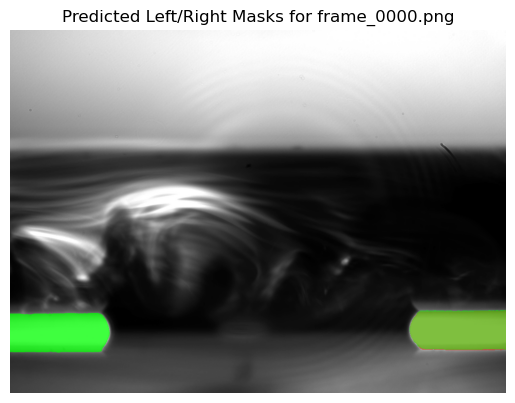

  1%|          | 1/103 [00:01<01:52,  1.11s/it]

Extracted features for 8 masks in frame_0005.png
[0 1 1 1 0 0 0 0]
Identified 3 edge masks in frame_0005.png


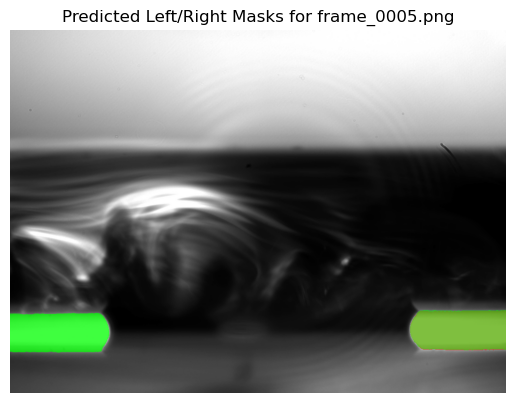

  6%|▌         | 6/103 [00:02<00:30,  3.15it/s]

Extracted features for 9 masks in frame_0010.png
[0 1 1 1 0 0 0 0 0]
Identified 3 edge masks in frame_0010.png


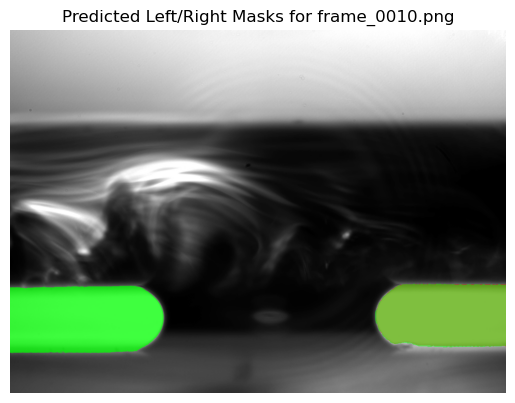

 11%|█         | 11/103 [00:03<00:23,  3.87it/s]

Extracted features for 7 masks in frame_0015.png
[1 1 1 0 0 0 0]
Identified 3 edge masks in frame_0015.png


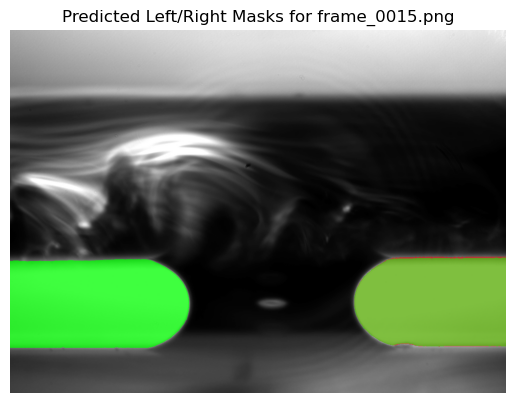

 16%|█▌        | 16/103 [00:04<00:19,  4.43it/s]

Extracted features for 6 masks in frame_0020.png
[0 1 1 1 0 0]
Identified 3 edge masks in frame_0020.png


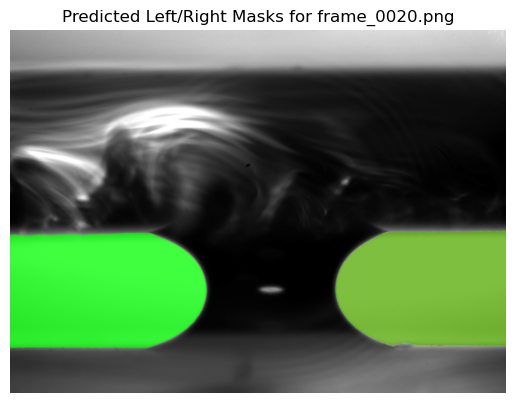

 20%|██        | 21/103 [00:04<00:16,  4.93it/s]

Extracted features for 8 masks in frame_0025.png
[1 1 1 0 0 0 0 0]
Identified 3 edge masks in frame_0025.png


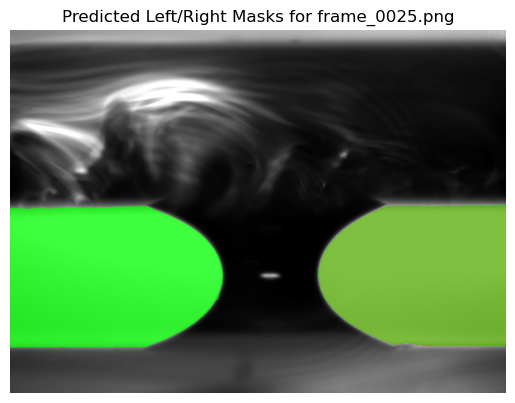

 25%|██▌       | 26/103 [00:05<00:15,  4.90it/s]

Extracted features for 7 masks in frame_0030.png
[1 1 0 0 0 1 0]
Identified 3 edge masks in frame_0030.png


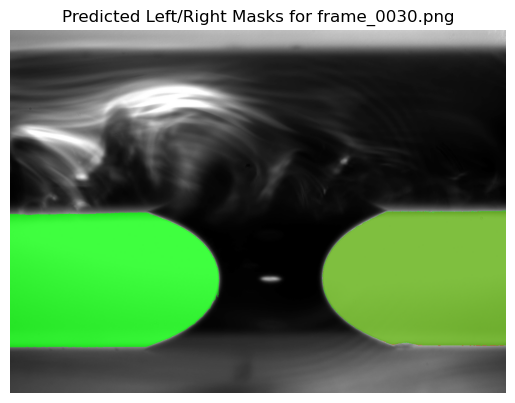

 30%|███       | 31/103 [00:07<00:16,  4.44it/s]

Extracted features for 7 masks in frame_0035.png
[0 1 1 1 0 0 0]
Identified 3 edge masks in frame_0035.png


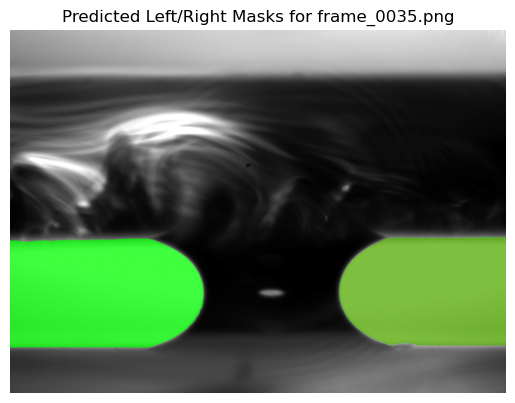

 35%|███▍      | 36/103 [00:08<00:15,  4.37it/s]

Extracted features for 11 masks in frame_0040.png
[1 1 0 1 0 0 0 0 0 0 0]
Identified 3 edge masks in frame_0040.png


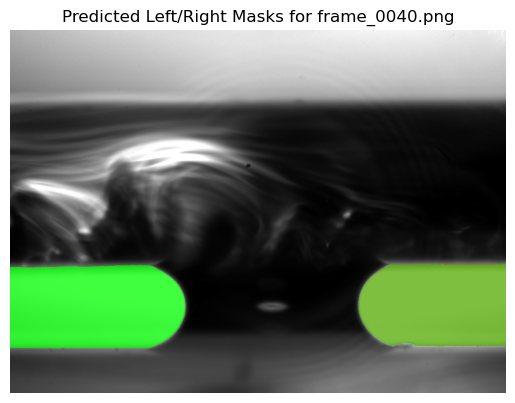

 40%|███▉      | 41/103 [00:10<00:15,  3.90it/s]

Extracted features for 10 masks in frame_0045.png
[1 1 1 0 0 0 0 0 0 0]
Identified 3 edge masks in frame_0045.png


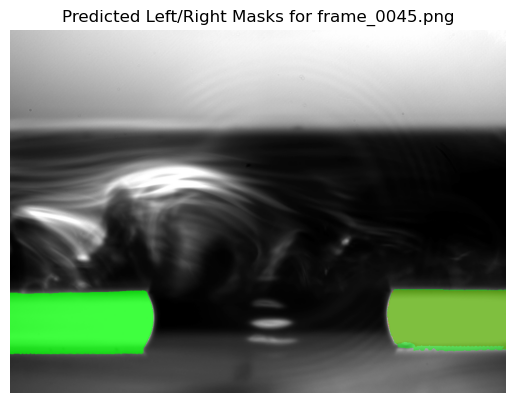

 45%|████▍     | 46/103 [00:11<00:15,  3.76it/s]

Extracted features for 9 masks in frame_0050.png
[1 1 1 0 0 0 0 0 0]
Identified 3 edge masks in frame_0050.png


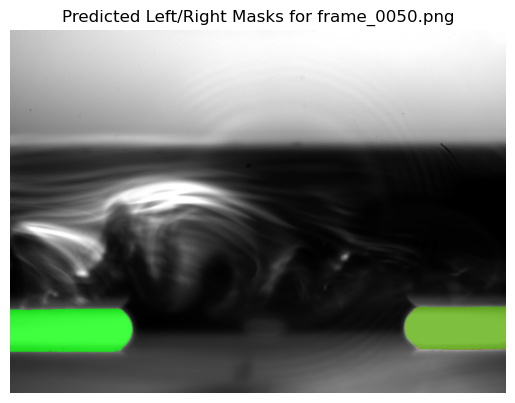

 50%|████▉     | 51/103 [00:13<00:14,  3.53it/s]

Extracted features for 9 masks in frame_0055.png
[1 1 0 0 0 0 0 0 1]
Identified 3 edge masks in frame_0055.png


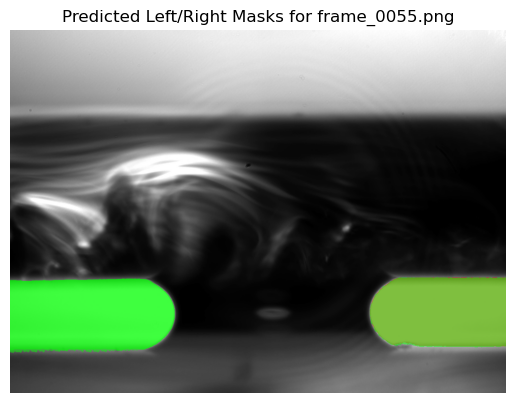

 54%|█████▍    | 56/103 [00:14<00:13,  3.60it/s]

Extracted features for 7 masks in frame_0060.png
[1 1 1 0 0 0 0]
Identified 3 edge masks in frame_0060.png


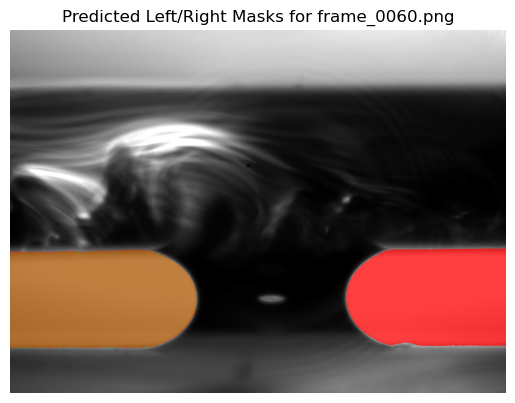

 59%|█████▉    | 61/103 [00:15<00:11,  3.70it/s]

Extracted features for 8 masks in frame_0065.png
[1 0 1 0 0 1 0 0]
Identified 3 edge masks in frame_0065.png


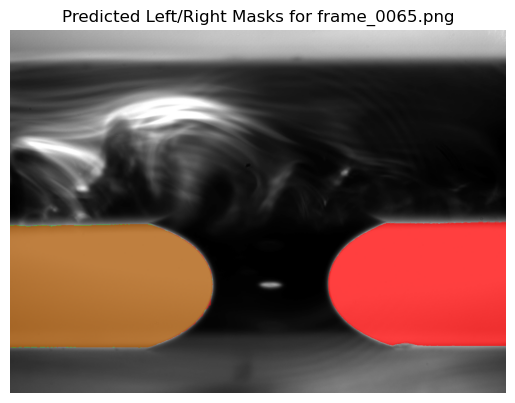

 64%|██████▍   | 66/103 [00:17<00:10,  3.69it/s]

Extracted features for 6 masks in frame_0070.png
[1 1 1 0 0 0]
Identified 3 edge masks in frame_0070.png


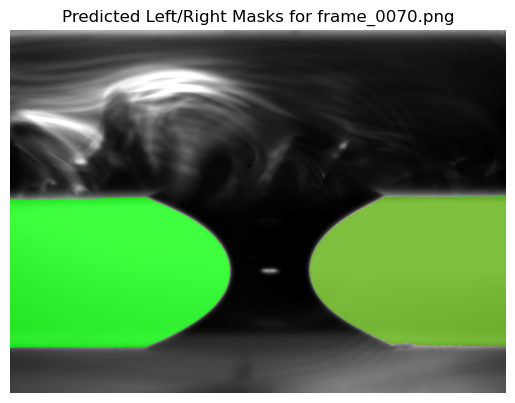

 69%|██████▉   | 71/103 [00:18<00:08,  3.85it/s]

Extracted features for 7 masks in frame_0075.png
[1 0 1 0 0 0 1]
Identified 3 edge masks in frame_0075.png


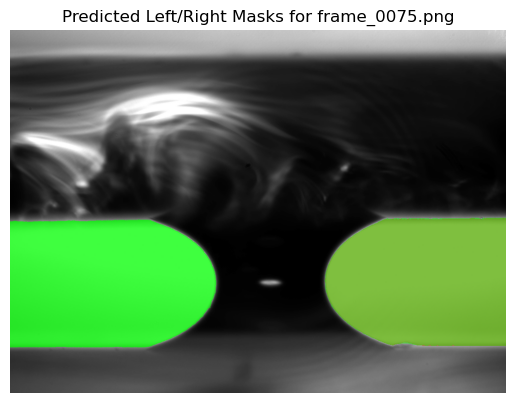

 74%|███████▍  | 76/103 [00:19<00:06,  3.94it/s]

Extracted features for 7 masks in frame_0080.png
[1 1 1 0 0 0 0]
Identified 3 edge masks in frame_0080.png


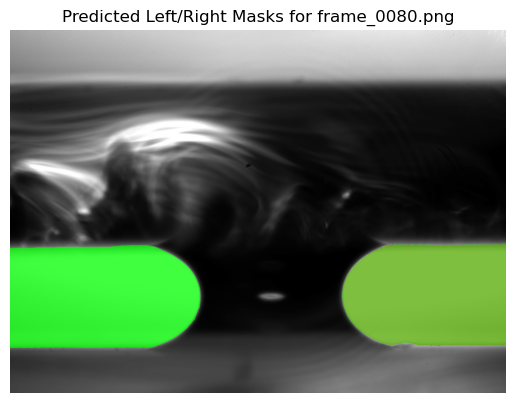

 79%|███████▊  | 81/103 [00:20<00:05,  4.03it/s]

Extracted features for 9 masks in frame_0085.png
[1 0 1 1 0 0 0 0 0]
Identified 3 edge masks in frame_0085.png


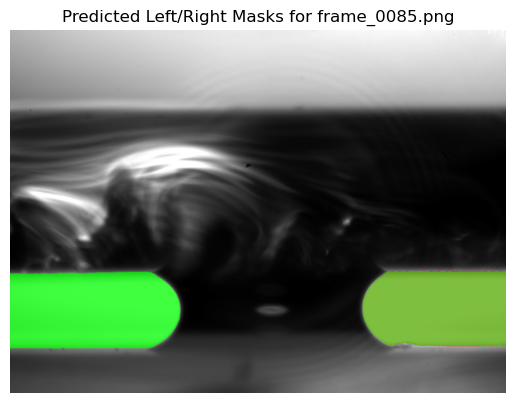

 83%|████████▎ | 86/103 [00:22<00:04,  3.90it/s]

Extracted features for 9 masks in frame_0090.png
[1 1 0 0 0 0 1 0 0]
Identified 3 edge masks in frame_0090.png


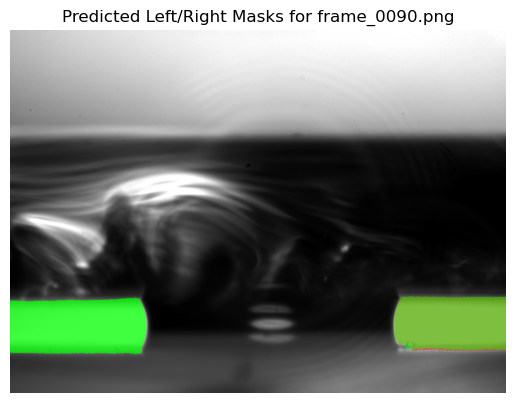

 88%|████████▊ | 91/103 [00:23<00:03,  3.72it/s]

Extracted features for 11 masks in frame_0095.png
[1 0 1 1 0 0 0 0 0 0 0]
Identified 3 edge masks in frame_0095.png


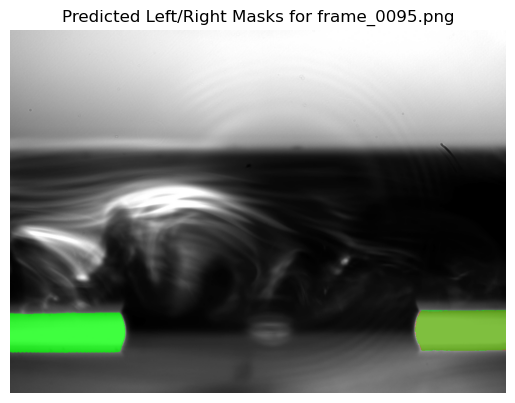

 93%|█████████▎| 96/103 [00:25<00:02,  3.45it/s]

Extracted features for 11 masks in frame_0100.png
[1 1 0 1 0 0 0 0 0 0 0]
Identified 3 edge masks in frame_0100.png


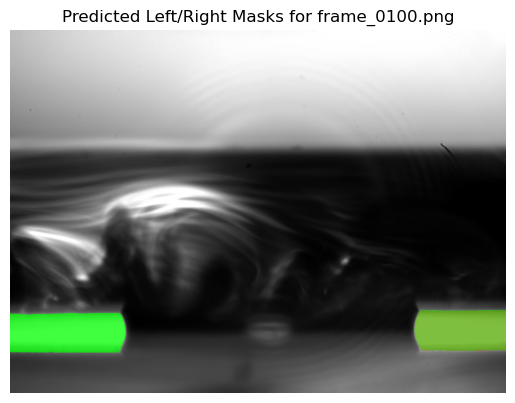

100%|██████████| 103/103 [00:27<00:00,  3.81it/s]


<Figure size 640x480 with 0 Axes>

In [12]:
%matplotlib inline
%run Analysis_Files/Classifier_files/Use_classifier.py

# 3. Run force analysis

In [13]:
%run -i Analysis_Files\plot_forces_multiprocessing.py

Found 103 images in D:\Capillary_bridging_data_alannah\Silane Capillary Action\3aminopropyl_07.22_Trial3_VidImages


100%|██████████| 103/103 [01:04<00:00,  1.60it/s]



✅ Results saved to: D:\Capillary_bridging_data_alannah\Silane Capillary Action\3aminopropyl_07.22_Trial3_VidImages\Output_Trial3\Alannah_S1_training.xlsx


C:\Users\alann\OneDrive\Documents\GitHub\Capillary_Liquid_Bridges\Analysis_Files\plot_forces_multiprocessing.py:160: RuntimeWarning: Mean of empty slice
  Average = np.nanmean([f_lt, f_rt, f_lb, f_rb], axis=0)
C:\Users\alann\OneDrive\Documents\GitHub\Capillary_Liquid_Bridges\Analysis_Files\plot_forces_multiprocessing.py:161: RuntimeWarning: Mean of empty slice
  Average_circle = np.nanmean([f_lt_circle, f_rt_circle, f_lb_circle, f_rb_circle], axis=0)


# 4. Display Final Plot

C:\Users\alann\OneDrive\Documents\GitHub\Capillary_Liquid_Bridges\Analysis_Files\Plot_from_excel.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', n_segments +1)


Plot saved to: D:\Capillary_bridging_data_alannah\Silane Capillary Action\3aminopropyl_07.22_Trial3_VidImages\Output_Trial3\capillary_bridge_forces_vs_plate_separation.png


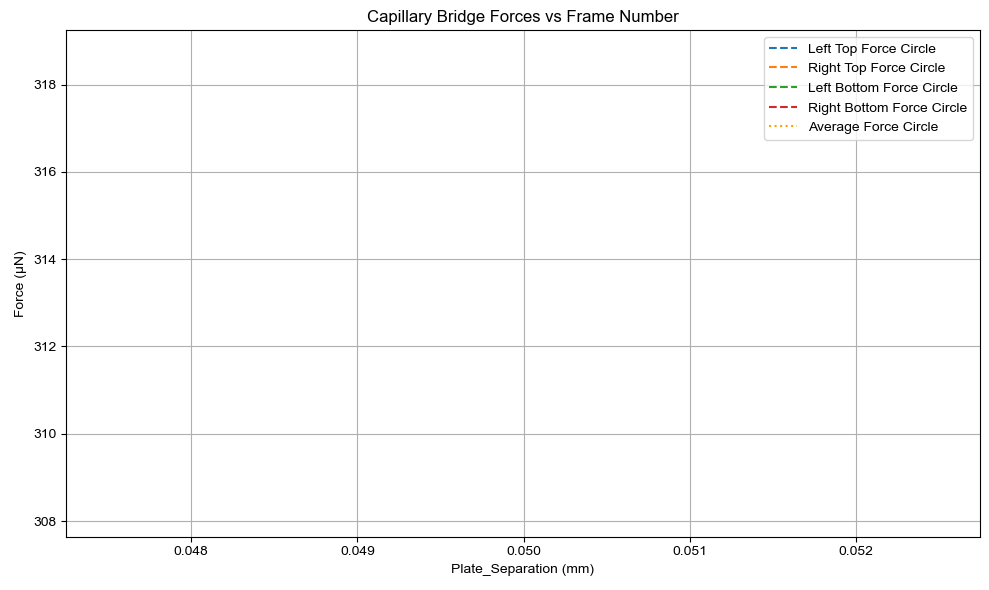

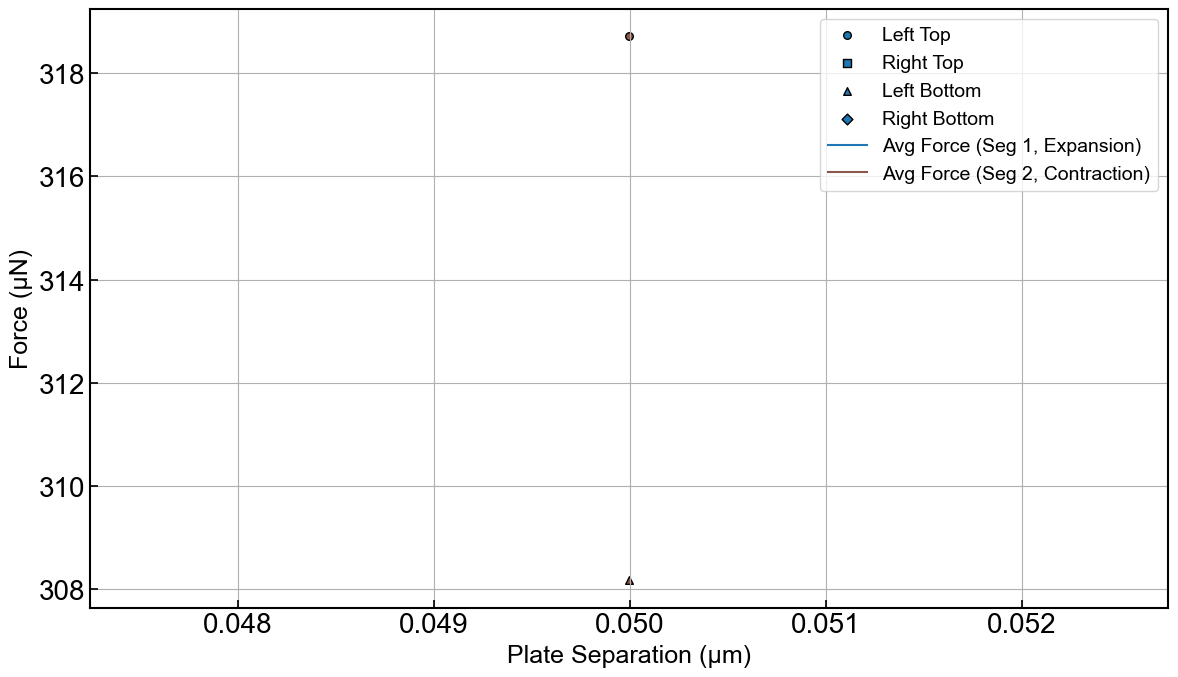

<Figure size 640x480 with 0 Axes>

In [14]:
%matplotlib inline
%run -i Analysis_Files/Plot_from_excel.py